In [1]:
import mdtraj as md
import nglview as nv
import numpy as np
import matplotlib.pyplot as plt

# carica traiettoria
traj = md.load("traj_fit.xtc", top="../npt.pdb")
frame0 = traj[0]

view = nv.show_mdtraj(traj)

view.clear_representations(component=0)

# proteina in cartoon
view.add_cartoon(
    component=0,
    selection="protein",
    color="blue"
)

# residuo 6 in licorice (componente 0 - traiettoria)
view.add_licorice(
    component=0,
    selection="6",  # oppure ":6" o "resid 6"
    color="red"
)

# ---------- COMPONENT 1: frame statico (grigio) ----------
view.add_component(frame0)
view.clear_representations(component=1)

# proteina in cartoon
view.add_cartoon(
    component=1,
    selection="protein",
    color="grey"
)

# residuo 6 in licorice (componente 0 - traiettoria)
view.add_licorice(
    component=1,
    selection="6",
    color="grey"
)


view



/home/tedeschg/miniforge3/envs/cvformer/lib/python3.10/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


NGLWidget(max_frame=10000)

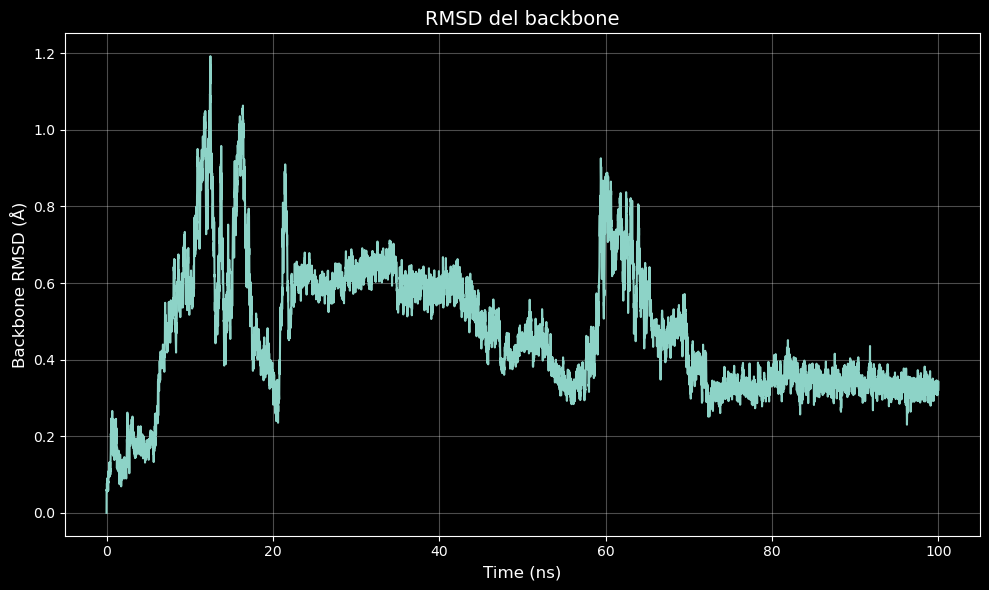

In [2]:


backbone = traj.topology.select("backbone")

rmsd = md.rmsd(traj, traj[0], atom_indices=backbone)


# tempo in ns (assumendo che ogni frame sia salvato ogni X ps)
# modifica dt in base al tuo setup (es. 10 ps = 0.01 ns)
time_ns = np.arange(len(rmsd)) * 0.01  # esempio: frame ogni 10 ps

# plot
plt.figure(figsize=(10, 6))
plt.plot(time_ns, rmsd, linewidth=1.5)
plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Backbone RMSD (Å)", fontsize=12)
plt.title("RMSD del backbone", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()